# Experiment 10: bucket adjustment audit

- Runs Nevermore for a set of targets/baseline ligands (edit run definitions below).
- Captures ligand bucket adjustments per run and writes CSVs under `nevermore/notebooks/exp10_runs`.
- Builds an aggregated CSV and a bucket frequency table across runs.
- Provides quick overlap plots (Venn when 2-3 runs are selected) plus pointers to the optimization traces (loss/affinity/ADMET).


In [2]:
# Ensure repo on sys.path (works when run from CLI or inside the notebook directory)
import sys
from pathlib import Path

repo_root = Path.cwd()
if '__file__' in globals():
    repo_root = Path(__file__).resolve().parents[2]

marker = Path('nevermore/configs/default.yaml')
for parent in [repo_root] + list(repo_root.parents):
    if (parent / marker).exists():
        repo_root = parent
        break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Repo root:', repo_root)


Repo root: /scratch/home/sr3622/Firm-DTI/Firm-DTI2


In [3]:
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from nevermore.pipeline import NevermorePipeline, load_config


In [11]:
EXPERIMENT_NAME = "affinity"
BASE_CONFIG_PATH = repo_root / "nevermore" / "configs" / "default.yaml"
OUTPUT_DIR = repo_root/ f"exp10_runs_menin"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Configure runs

Edit `RUN_COUNT` or `run_definitions` to choose targets/config tweaks. `GLOBAL_OVERRIDES` applies to all runs (e.g., change ligand feature count, budgets, retrieval limits); per-run `overrides` can override those. Set `RUN_UP_TO` to `'optimization'` if you want to skip retrieval.


In [ ]:


base_cfg = load_config(BASE_CONFIG_PATH)
base_cfg.docking.enabled = False
base_cfg.visualization.enabled = False


RUN_COUNT = 1  # adjust as needed
RUN_UP_TO = "optimization"  # set to "optimization" to skip retrieval
GLOBAL_OVERRIDES = {
}

run_definitions = []
run_definitions.append(
    {
        "label": f"{EXPERIMENT_NAME}_sample",

        "target_sequence": "SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ",
        "baseline_smiles": "CN(C)CCCSC1=CC=CC=C1NC(=O)/C=C/C2=CC=CC=C2",

        # "target_sequence":"MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEHFLAVNRVIPTNVPELTFQPSPAPDPPGGLTYFPVADLSIIAALYARFTAQIRGAVDLSLYPREGGVSSRELVKKVSDVIWNSLSRSYFKDRAHIQSLFSFITGTKLDSSGVAFAVVGACQALGLRDVHLALSEDHAWVVFGPNGEQTAEVTWHGKGNEDRRGQTVNAGVAERSWLYLKGSYMRCDRKMEVAFMVCAINPSIDLHTDSLELLQLQQKLLWLLYDLGHLERYPMALGNLADLEELEPTPGRPDPLTLYHKGIASAKTYYRDEHIYPYMYLAGYHCRNRNVREALQAWADTATVIQDYNYCREDEEIYKEFFEVANDVIPNLLKEAASLLEAGEERPGEQSQGTQSQGSALQDPECFAHLLRFYDGICKWEEGSPTPVLHVGWATFLVQSLGRFEGQVRQKVRIVSREAEAAEAEEPWGEEAREGRRRGPRRESKPEEPPPPKKPALDKGLGTGQGAVSGPPRKPPGTVAGTARGPEGGSTAQVPAPTASPPPEGPVLTFQSEKMKGMKELLVATKINSSAIKLQLTAQSQVQMKKQKVSTPSDYTLSFLKRQRKGL",
        # "baseline_smiles":"CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2(C1)CCN(C[C@H]1CC[C@@H](CC1)NS(=O)(=O)CC)CC2",
        "overrides": {},
    }
)

print(f"Prepared {len(run_definitions)} runs -> saving outputs to {OUTPUT_DIR}")


Prepared 1 runs -> saving outputs to /scratch/home/sr3622/Firm-DTI/Firm-DTI2/exp10_runs


In [5]:
def apply_overrides(cfg, overrides):
    for section, params in (overrides or {}).items():
        if not hasattr(cfg, section):
            continue
        section_obj = getattr(cfg, section)
        for key, val in (params or {}).items():
            if hasattr(section_obj, key):
                setattr(section_obj, key, val)


def run_single(run_def, base_cfg, up_to=RUN_UP_TO):
    cfg = copy.deepcopy(base_cfg)
    opt_cfg = cfg.optimization
    opt_cfg.target_sequence = run_def["target_sequence"]
    opt_cfg.baseline_smiles = run_def["baseline_smiles"]

    apply_overrides(cfg, run_def.get("overrides"))

    pipe = NevermorePipeline(config=cfg)
    results = pipe.run(up_to=up_to, verbose=True)
    return cfg, results


def collect_bucket_adjustments(summary_csv):
    df = pd.read_csv(summary_csv)
    if df.empty or "feature_type" not in df.columns:
        return pd.DataFrame()
    lig = df[df["feature_type"] == "ligand"].copy()
    if lig.empty:
        return lig
    lig["feature_index"] = lig["feature_index"].astype(int)
    lig["adjustment"] = lig["adjustment"].astype(float)
    lig["baseline"] = lig["baseline"].astype(float)
    lig["new_value"] = lig["new_value"].astype(float)
    return lig[lig["adjustment"] != 0].sort_values("feature_index")


In [6]:
combined = []
bucket_sets = {}
run_summaries = []

for run_def in tqdm(run_definitions, desc="nevermore runs"):
    cfg, res = run_single(run_def, base_cfg, up_to=RUN_UP_TO)
    opt_res = res["optimization"]
    summary_csv = opt_res.outputs["summary"]

    adj_df = collect_bucket_adjustments(summary_csv)
    adj_df["run_label"] = run_def["label"]
    adj_df["optimization_signature"] = opt_res.signature


    per_run_csv = OUTPUT_DIR / f"{run_def['label']}_bucket_adjustments.csv"
    adj_df.to_csv(per_run_csv, index=False)

    bucket_sets[run_def["label"]] = set(adj_df["feature_index"].astype(int)) if not adj_df.empty else set()
    combined.append(adj_df)

    run_summaries.append(
        {
            "run_label": run_def["label"],
            "dataset_index": run_def.get("dataset_index"),
            "optimization_signature": opt_res.signature,
            "buckets_touched": len(bucket_sets[run_def["label"]]),
            "per_run_csv": str(per_run_csv),
            "summary_csv": str(summary_csv),
            "trace_csv": str(opt_res.outputs.get("trace")) if opt_res.outputs.get("trace") else None,
            "topk_trace_csv": str(opt_res.outputs.get("topk_stats")) if opt_res.outputs.get("topk_stats") else None,
            "baseline_affinity": opt_res.details.get("baseline_affinity"),
            "optimized_affinity": opt_res.details.get("optimized_affinity"),
        }
    )

combined_df = pd.concat(combined, ignore_index=True) if combined else pd.DataFrame()
combined_out = OUTPUT_DIR / f"{EXPERIMENT_NAME}_bucket_adjustments_all.csv"
combined_df.to_csv(combined_out, index=False)

run_summary_df = pd.DataFrame(run_summaries)
run_summary_out = OUTPUT_DIR / f"{EXPERIMENT_NAME}_run_summary.csv"
run_summary_df.to_csv(run_summary_out, index=False)

if not combined_df.empty and "adjustment" in combined_df.columns:
    bucket_freq = (
        combined_df[combined_df["adjustment"] != 0]
        .groupby("feature_index")["run_label"]
        .nunique()
        .reset_index()
        .rename(columns={"run_label": "run_count"})
        .sort_values("run_count", ascending=False)
    )
else:
    bucket_freq = pd.DataFrame(columns=["feature_index", "run_count"])
bucket_freq_out = OUTPUT_DIR / f"{EXPERIMENT_NAME}_bucket_frequency.csv"
bucket_freq.to_csv(bucket_freq_out, index=False)

if run_summary_df.empty:
    print("No runs completed yet. Check configuration above.")
else:
    display(run_summary_df.head())
    print(f"Saved combined adjustments to {combined_out}")
    if combined_df.empty:
        print("No ligand bucket adjustments were recorded (all zero).")
    else:
        display(combined_df.head())
        display(bucket_freq.head())


nevermore runs:   0%|          | 0/1 [00:00<?, ?it/s]

[ingest] starting...
[ingest] cached (sig=d2f8d2740f3a)
[features] starting...
[features] cached (sig=329d35f96e63)
[optimization] starting...


/home/sr3622/miniconda3/envs/digress10/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/sr3622/miniconda3/envs/digress10/lib/python3.10/site-packages/nevergrad/parametrization/_datalayers.py:107: NevergradRuntimeWarning: Bounds are 1.9918646812438965 sigma away from each other at the closest, you should aim for at least 3 for better quality.
  warnings.warn(
nevermore runs: 100%|██████████| 1/1 [01:05<00:00, 65.40s/it]

[optimization] done (sig=df32e60d693e)


,run_label,dataset_index,optimization_signature,buckets_touched,per_run_csv,summary_csv,trace_csv,topk_trace_csv,baseline_affinity,optimized_affinity
0,affinity_sample,None,df32e60d693e,12,/scratch/home/sr3622/Firm-DTI/Firm-DTI2/exp10_...,/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeli...,/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeli...,/scratch/home/sr3622/Firm-DTI/Firm-DTI2/pipeli...,8.266292,8.28392


Saved combined adjustments to /scratch/home/sr3622/Firm-DTI/Firm-DTI2/exp10_runs/affinity_bucket_adjustments_all.csv


,feature_type,feature_index,baseline,new_value,adjustment,abs_adjustment,run_label,optimization_signature
0,ligand,13,0.0,1.0,1.0,1.0,affinity_sample,df32e60d693e
1,ligand,90,0.0,1.0,1.0,1.0,affinity_sample,df32e60d693e
2,ligand,191,0.0,1.0,1.0,1.0,affinity_sample,df32e60d693e
3,ligand,283,0.0,1.0,1.0,1.0,affinity_sample,df32e60d693e
4,ligand,314,0.0,1.0,1.0,1.0,affinity_sample,df32e60d693e


,feature_index,run_count
0,13,1
1,90,1
2,191,1
3,283,1
4,314,1


Selected runs (raw): ['logP', 'QED', 'hERG', 'all', 'affinity', 'All']
Ordered runs (color order): ['logP', 'QED', 'hERG', 'affinity', 'all', 'All']


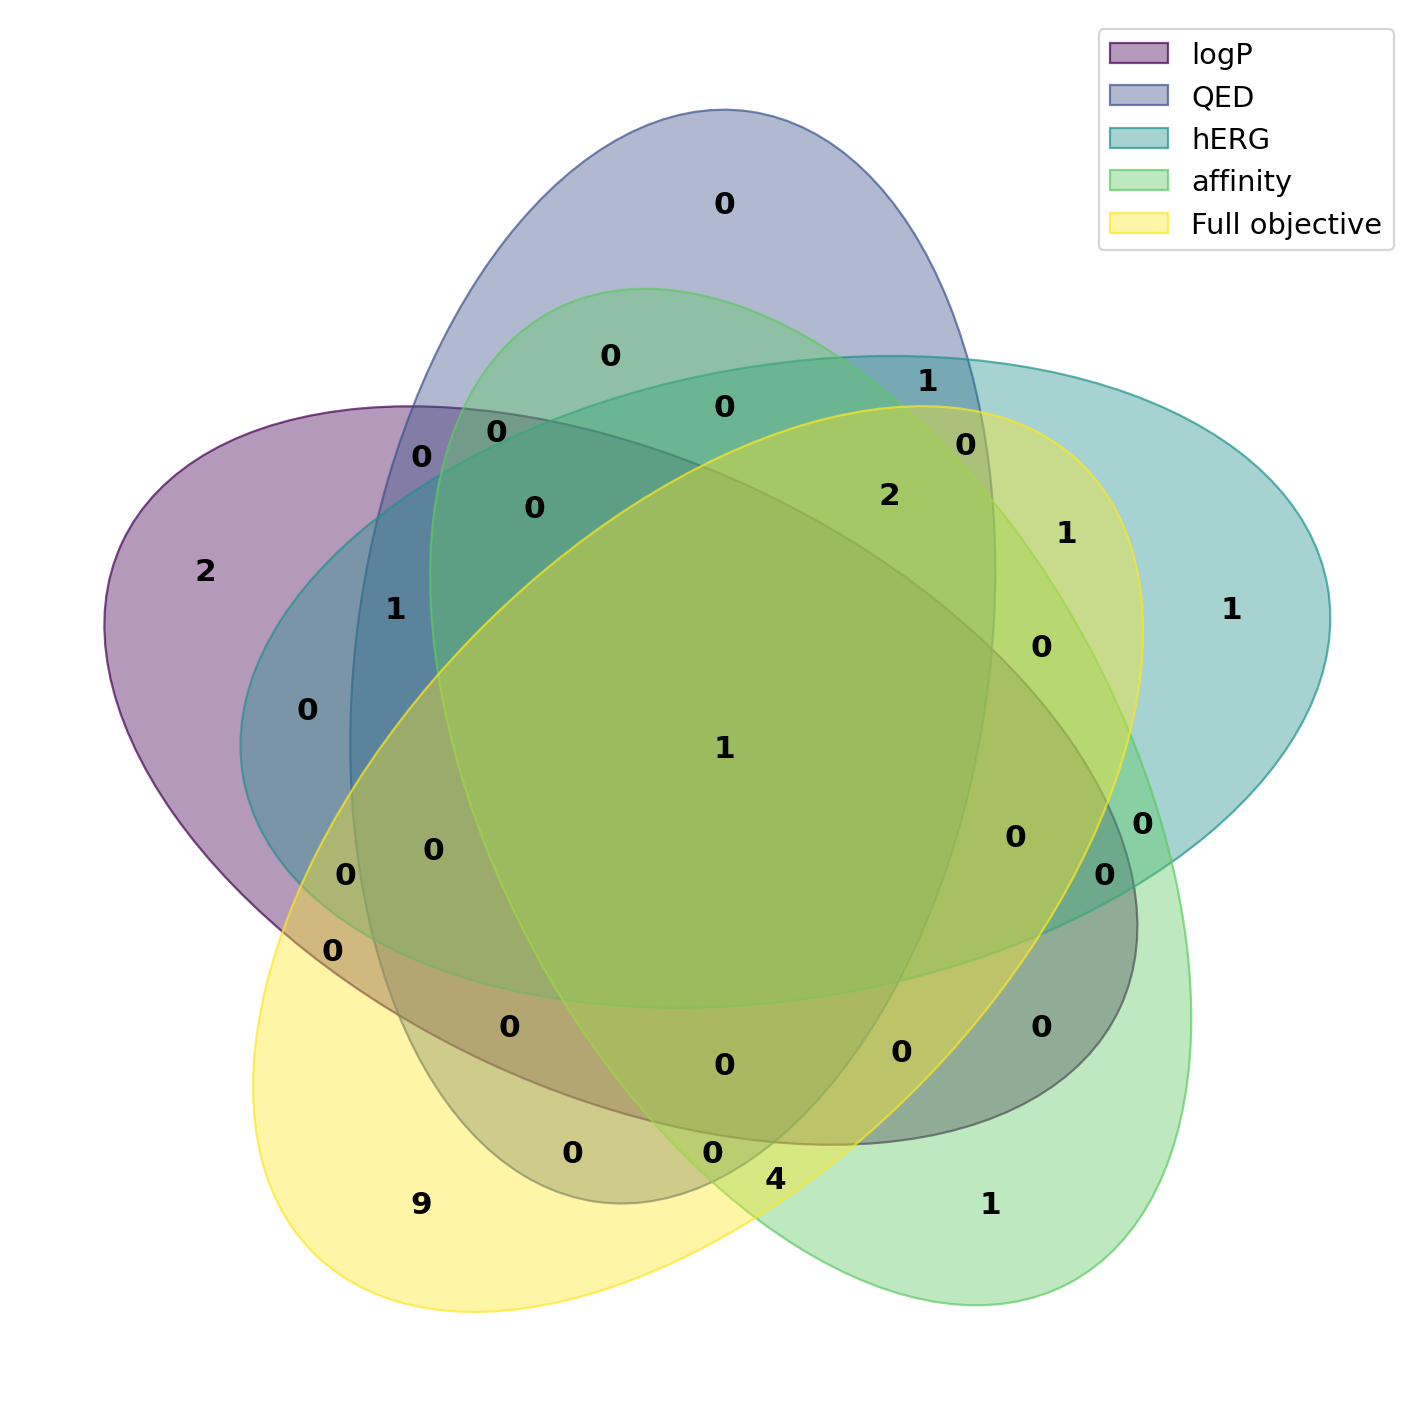

In [12]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from venn import venn
import textwrap


# -------------------- load bucket sets --------------------
base = repo_root if "repo_root" in globals() else Path.cwd()
run_dirs = [p for p in base.glob("*_runs") if p.is_dir()]
if "OUTPUT_DIR" in globals():
    run_dirs.append(Path(OUTPUT_DIR))
run_dirs = sorted(list(dict.fromkeys(run_dirs)))  # dedupe

bucket_sets = {}
for run_dir in run_dirs:
    for path in run_dir.glob("*_bucket_adjustments.csv"):
        if "bucket_adjustments_all" in path.name:
            continue
        label = path.stem.replace("_sample_bucket_adjustments", "").replace("_bucket_adjustments", "")
        df = pd.read_csv(path)
        if not df.empty and "feature_index" in df.columns:
            bucket_sets[label] = set(df["feature_index"].dropna().astype(int))
        else:
            bucket_sets[label] = set()

selected = list(bucket_sets.keys())
print("Selected runs (raw):", selected)

# -------------------- pretty label helper --------------------
def pretty_label(s, width=22):
    s = str(s).strip()

    # ✅ rename "all" label in plot (optional)
    if s.lower() == "all":
        s = "Full objective"  # change text if you want

    s = s.replace("_", " ")
    return "\n".join(textwrap.wrap(s, width=width))

# -------------------- FORCE ORDER (controls color order) --------------------
preferred_order = ["logP", "QED", "hERG", "affinity", "all"]

def canon(s: str) -> str:
    # normalize labels so "logP", "logp", "log_P" all match
    return str(s).strip().lower().replace("_", "").replace(" ", "")

ordered_selected = []
used = set()

# add preferred objectives in order if present
for want in preferred_order:
    w = canon(want)
    for lab in selected:
        if canon(lab) == w and lab not in used:
            ordered_selected.append(lab)
            used.add(lab)
            break

# append any extras not in preferred_order (stable)
ordered_selected += sorted([lab for lab in selected if lab not in used], key=lambda x: x.lower())

print("Ordered runs (color order):", ordered_selected)

# -------------------- plot --------------------
if not ordered_selected:
    print("Nothing to plot yet (no runs selected).")
elif all(len(bucket_sets.get(lab, set())) == 0 for lab in ordered_selected):
    print("No bucket adjustments available to plot.")
else:
    # Build dict in forced order (dict insertion order => venn color order)
    # If you want to DROP empties, add: if len(bucket_sets.get(lab,set()))>0
    sets = {pretty_label(lab): set(bucket_sets.get(lab, set())) for lab in ordered_selected}

    fig, ax = plt.subplots(figsize=(12, 9), dpi=160)
    venn(sets, ax=ax)

    ax.set_axis_off()

    # style ALL text objects (labels + region numbers)
    for t in ax.texts:
        txt = t.get_text().strip()
        if txt.isdigit():
            t.set_fontsize(14)
            t.set_fontweight("bold")
        else:
            t.set_fontsize(13)
            t.set_fontweight("bold")

    plt.tight_layout()
    plt.savefig("venn_plot_sars.png", dpi=100)
    plt.show()


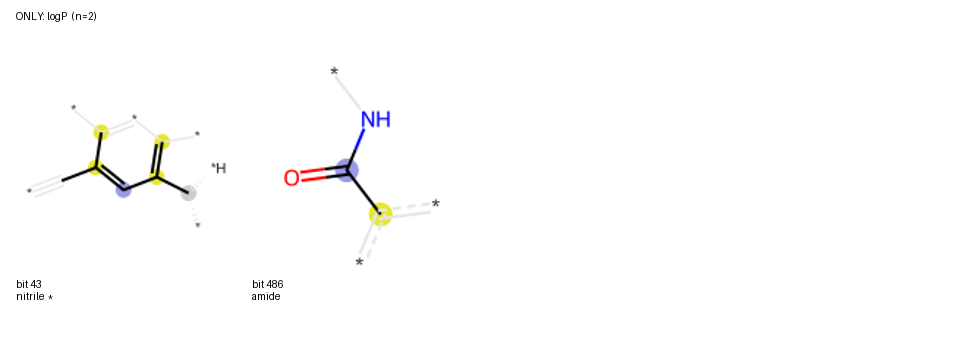

Bit -> label (heuristic):
ONLY: logP  (n=2)
  bit 43: nitrile *
  bit 486: amide
Note: '*' means the group was detected only after expanding the env radius for labeling.



[11:56:06] non-ring atom 0 marked aromatic
[11:56:06] non-ring atom 0 marked aromatic


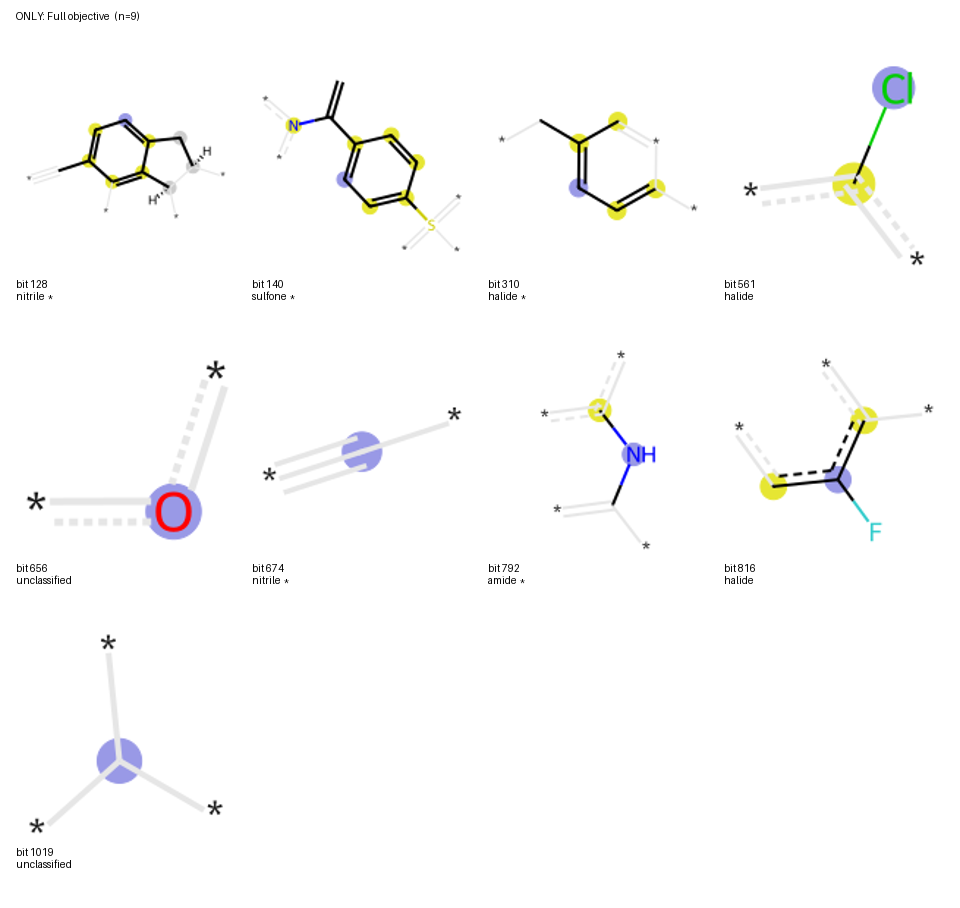

Bit -> label (heuristic):
ONLY: Full objective  (n=9)
  bit 128: nitrile *
  bit 140: sulfone *
  bit 310: halide *
  bit 561: halide
  bit 656: unclassified
  bit 674: nitrile *
  bit 792: amide *
  bit 816: halide
  bit 1019: unclassified
Note: '*' means the group was detected only after expanding the env radius for labeling.



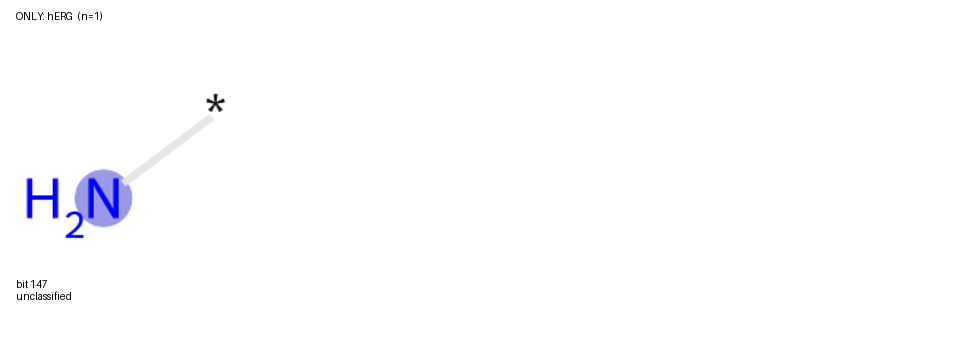

Bit -> label (heuristic):
ONLY: hERG  (n=1)
  bit 147: unclassified
Note: '*' means the group was detected only after expanding the env radius for labeling.



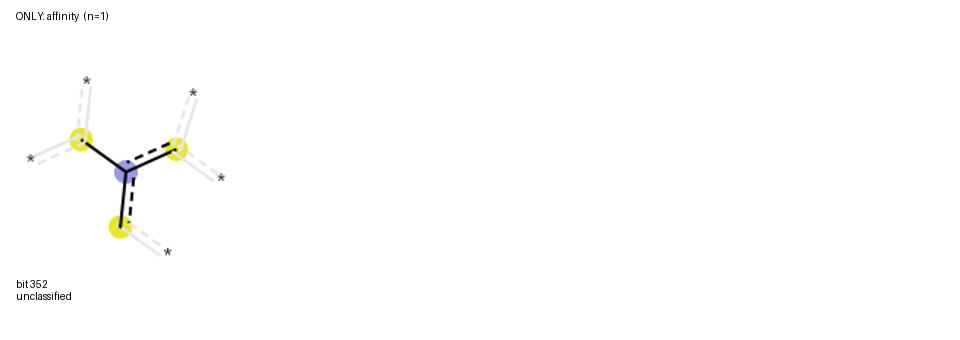

Bit -> label (heuristic):
ONLY: affinity  (n=1)
  bit 352: unclassified
Note: '*' means the group was detected only after expanding the env radius for labeling.



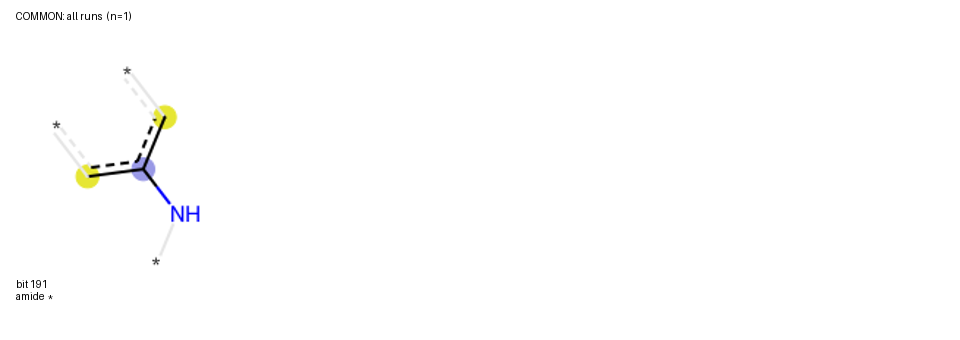

Bit -> label (heuristic):
COMMON: all runs  (n=1)
  bit 191: amide *
Note: '*' means the group was detected only after expanding the env radius for labeling.



In [13]:
# -------------------- decode bits -> RDKit Morgan-bit environments + functional-group labels --------------------

# Core imports
from pathlib import Path

try:
    import pandas as pd
except ImportError:
    pd = None

# RDKit + display
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Draw, Fragments
    from IPython.display import display
except ImportError:
    Chem = None

# -------------------- Bit-region helpers --------------------
def _bit_membership_regions(sets, labels):
    """Group bits by membership pattern across labels."""
    union_bits = set().union(*[sets[l] for l in labels]) if labels else set()
    pattern2bits = {}
    for b in sorted(union_bits):
        pattern = tuple(b in sets[l] for l in labels)
        pattern2bits.setdefault(pattern, []).append(b)
    return pattern2bits

def _pattern_name(pattern, labels):
    in_labs = [lab for lab, on in zip(labels, pattern) if on]
    if len(in_labs) == 0:
        return "none"
    if len(in_labs) == 1:
        return f"ONLY: {in_labs[0]}"
    if len(in_labs) == len(labels):
        return "COMMON: all runs"
    return " & ".join(in_labs)

# -------------------- Find representative molecules for bits --------------------
def _find_representative_mols_for_bits(bits, smiles_list, radius=3, nBits=1024, max_scan=50000):
    """
    For each bit, find ONE molecule in smiles_list that contains it and store its bitInfo.
    Returns dict: bit -> (mol, bitInfo)
    """
    rep = {}
    missing = set(bits)

    scanned = 0
    for smi in smiles_list:
        if not missing:
            break
        scanned += 1
        if scanned > max_scan:
            break

        m = Chem.MolFromSmiles(str(smi))
        if m is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits, bitInfo=bitInfo)
        on = set(fp.GetOnBits())

        hit = list(on & missing)
        for b in hit:
            rep[b] = (m, bitInfo)
        missing -= set(hit)

    return rep, missing

# -------------------- Functional-group labeling (improved) --------------------
# 1) SMARTS list (specific-first). You can extend this list anytime.
_FG_SMARTS = [
    # sulfur / thiocarbonyl family
    ("dithiocarbamate", "[NX3,NX4+][CX3](=[SX1])[SX2]"),
    ("thiourea",        "[NX3][CX3](=[SX1])[NX3]"),
    ("thioamide",       "[NX3][CX3](=[SX1])"),
    ("thioester",       "[CX3](=[OX1])[SX2]"),
    ("thiocarbonyl",    "[CX3](=[SX1])"),

    # sulfonyl family
    ("sulfonamide",     "[SX4](=[OX1])(=[OX1])[NX3]"),
    ("sulfonate ester", "[SX4](=[OX1])(=[OX1])[OX2][#6]"),
    ("sulfone",         "[SX4](=[OX1])(=[OX1])"),
    ("sulfoxide",       "[SX3](=[OX1])"),

    # carbonyl family
    ("anhydride",       "[CX3](=[OX1])[OX2][CX3](=[OX1])"),
    ("imide",           "[NX3][CX3](=[OX1])[CX3](=[OX1])"),
    ("carbamate",       "[OX2][CX3](=[OX1])[NX3]"),
    ("urea",            "[NX3][CX3](=[OX1])[NX3]"),
    ("amide",           "[CX3](=[OX1])[NX3]"),
    ("ester",           "[CX3](=[OX1])[OX2][#6]"),
    ("carboxylic acid", "[CX3](=[OX1])[OX2H1]"),
    ("carboxylate",     "[CX3](=[OX1])[OX1-]"),
    ("aldehyde",        "[CX3H1](=[OX1])[#6]"),
    ("ketone",          "[#6][CX3](=[OX1])[#6]"),

    # nitrogen groups
    ("guanidine",       "NC(=N)N"),
    ("amidine",         "[CX3](=[NX2])[NX3]"),
    ("nitro",           "[NX3+](=[OX1])[OX1-]"),
    ("azide",           "[NX3]=[NX2]=[NX1]"),
    ("nitrile",         "[CX2]#N"),

    # oxygen groups
    ("phenol",          "c[OX2H]"),
    ("alcohol",         "[OX2H][CX4;!$(C=O)]"),
    ("ether",           "[#6][OX2][#6]"),

    # other sulfur groups
    ("thiol",           "[SX2H]"),
    ("thioether",       "[#6][SX2][#6]"),
    ("disulfide",       "[SX2][SX2]"),

    ("halide",          "[F,Cl,Br,I]"),
]

def _compile_fg_smarts():
    compiled = []
    for name, smarts in _FG_SMARTS:
        q = Chem.MolFromSmarts(smarts)
        if q is not None:
            compiled.append((name, q))
    return compiled

_FG_QUERIES = None

# 2) RDKit Fragments fallback map (broad coverage)
_FRAGMENT_MAP = [
    ("amide", "fr_amide"),
    ("ester", "fr_ester"),
    ("carboxylic acid", "fr_Al_COO"),
    ("aromatic carboxylic acid", "fr_Ar_COO"),
    ("alcohol", "fr_Al_OH"),
    ("phenol", "fr_Ar_OH"),
    ("ether", "fr_ether"),
    ("ketone", "fr_ketone"),
    ("aldehyde", "fr_aldehyde"),
    ("nitro", "fr_nitro"),
    ("nitrile", "fr_nitrile"),
    ("sulfone", "fr_sulfone"),
    ("sulfonamide", "fr_sulfonamd"),
    ("thiol", "fr_SH"),
    ("thioether (sulfide)", "fr_sulfide"),
    ("urea", "fr_urea"),
    ("imide", "fr_imide"),
    ("halide", "fr_halogen"),
]

def _frag_hits(m):
    hits = []
    for label, fn_name in _FRAGMENT_MAP:
        fn = getattr(Fragments, fn_name, None)
        if fn is None:
            continue
        try:
            if fn(m) > 0:
                hits.append(label)
        except Exception:
            pass
    return hits

def _morgan_env_submol(mol, center_atom_idx: int, radius: int):
    """
    Build a sub-molecule corresponding to the Morgan atom environment (center, radius).
    """
    radius = int(radius)
    center_atom_idx = int(center_atom_idx)

    if radius <= 0:
        smi = Chem.MolFragmentToSmiles(mol, atomsToUse=[center_atom_idx], canonical=True)
        return Chem.MolFromSmiles(smi) if smi else None

    bond_ids = AllChem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom_idx)
    if not bond_ids:
        smi = Chem.MolFragmentToSmiles(mol, atomsToUse=[center_atom_idx], canonical=True)
        return Chem.MolFromSmiles(smi) if smi else None

    sub = Chem.PathToSubmol(mol, bond_ids)
    return sub

def _guess_groups(submol):
    """
    Return a priority-ordered list of group labels.
    Uses (1) SMARTS matches, then (2) RDKit fragment detectors.
    """
    global _FG_QUERIES
    if _FG_QUERIES is None:
        _FG_QUERIES = _compile_fg_smarts()

    found = []

    # SMARTS (specific)
    if submol is not None:
        for name, q in _FG_QUERIES:
            try:
                if submol.HasSubstructMatch(q):
                    found.append(name)
            except Exception:
                pass

    # Fragments (broad)
    if submol is not None:
        found.extend(_frag_hits(submol))

    # de-dup, preserve order
    out, seen = [], set()
    for x in found:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

def _guess_groups_with_radius_fallback(mol, center_atom_idx, base_radius, max_extra=2):
    """
    Try env at base_radius, then base_radius+1,... to capture full functional group.
    Returns (groups, used_radius, env_smiles_for_debug)
    """
    base_radius = int(base_radius)
    center_atom_idx = int(center_atom_idx)

    for extra in range(max_extra + 1):
        r = max(0, base_radius + extra)
        sub = _morgan_env_submol(mol, center_atom_idx, r)
        groups = _guess_groups(sub)
        if groups:
            smi = None
            try:
                smi = Chem.MolToSmiles(sub, canonical=True) if sub is not None else None
            except Exception:
                smi = None
            return groups, r, smi

    # still nothing
    smi = None
    try:
        sub0 = _morgan_env_submol(mol, center_atom_idx, base_radius)
        smi = Chem.MolToSmiles(sub0, canonical=True) if sub0 is not None else None
    except Exception:
        pass
    return [], base_radius, smi

# -------------------- Render grid with labels --------------------
def _show_bits_as_rdkit_grid(bits, rep_lookup, title, max_bits=24, mols_per_row=4, subimg=(220, 220)):
    """
    Render Morgan-bit environments as a grid using DrawMorganBit for each bit,
    and add a guessed functional-group label under each image.
    """
    from PIL import Image, ImageDraw, ImageFont

    bits = list(bits)[:max_bits]
    if not bits:
        print(f"{title}: (no bits)")
        return

    imgs = []
    legends = []
    bit2label = {}

    for b in bits:
        if b not in rep_lookup:
            continue
        mol, bitInfo = rep_lookup[b]

        # Draw the Morgan-bit environment image
        try:
            img = Draw.DrawMorganBit(mol, int(b), bitInfo, whichExample=0)  # PIL image
        except Exception:
            continue

        # Infer functional group label (with radius fallback)
        label = "unclassified"
        try:
            bb = int(b)
            if bb in bitInfo and len(bitInfo[bb]) > 0:
                center_atom_idx, rad = bitInfo[bb][0]
                groups, used_r, _env_smi = _guess_groups_with_radius_fallback(
                    mol, center_atom_idx, rad, max_extra=2
                )
                if groups:
                    label = ", ".join(groups[:2])  # top 1-2 groups
                    if used_r != int(rad):
                        label += " *"  # means: needed expanded radius to recognize
        except Exception:
            label = "unclassified"

        imgs.append(img.resize(subimg))
        legends.append(f"bit {b}\n{label}")
        bit2label[b] = label

    if not imgs:
        print(f"{title}: could not render any bits (no reps found).")
        return

    cols = max(1, mols_per_row)
    rows = (len(imgs) + cols - 1) // cols
    pad = 16
    label_h = 48  # enough for 2 lines

    W = cols * subimg[0] + (cols + 1) * pad
    H = rows * (subimg[1] + label_h) + (rows + 1) * pad + 40
    canvas = Image.new("RGB", (W, H), "white")
    draw = ImageDraw.Draw(canvas)

    draw.text((pad, 10), title, fill="black")

    try:
        font = ImageFont.load_default()
    except Exception:
        font = None

    for idx, (im, leg) in enumerate(zip(imgs, legends)):
        r = idx // cols
        c = idx % cols
        x = pad + c * (subimg[0] + pad)
        y = 40 + pad + r * (subimg[1] + label_h + pad)
        canvas.paste(im, (x, y))
        draw.multiline_text((x, y + subimg[1] + 2), leg, fill="black", font=font, spacing=2)

    display(canvas)

    # Optional: print clean mapping under each grid
    print("Bit -> label (heuristic):")
    print(title)
    for b in bits:
        if b in bit2label:
            print(f"  bit {b}: {bit2label[b]}")
    print("Note: '*' means the group was detected only after expanding the env radius for labeling.\n")

# -------------------- Main runner --------------------
# Expects:
#   - `sets` dict already exists: {run_label: set_of_bits, ...}
#   - optionally `repo_root` exists (Path); otherwise uses cwd
if Chem is None:
    print("RDKit not available. Install rdkit to use this.")
elif not isinstance(sets, dict) or len(sets) == 0:
    print("`sets` is missing/empty. Provide your sets dict: {label: set(bits)}")
elif pd is None:
    print("pandas not available (needed to read train.csv). Install pandas or pass smiles_list directly.")
else:
    labels = list(sets.keys())

    train_path = (repo_root if "repo_root" in globals() else Path.cwd()) / "data" / "train.csv"
    if not train_path.exists():
        print(f"Cannot decode bits: missing {train_path}")
    else:
        train_df = pd.read_csv(train_path)
        smiles_col = "Drug"  # adjust if needed
        smiles_list = train_df[smiles_col].astype(str).tolist()

        # Must match your fingerprint definition
        radius, nBits = 3, 1024

        # Group bits by overlap regions
        pattern2bits = _bit_membership_regions(sets, labels)

        # Decode representatives for all bits in any region
        all_bits = set().union(*pattern2bits.values()) if pattern2bits else set()
        rep_lookup, missing = _find_representative_mols_for_bits(
            all_bits, smiles_list, radius=radius, nBits=nBits, max_scan=80000
        )

        if missing:
            print(f"Warning: could not find representative molecules for {len(missing)} bits "
                  f"(could be collisions, different nBits/radius, or not present in train).")

        # 1) bits unique to each run (ONLY)
        for pattern, bits in pattern2bits.items():
            if sum(pattern) == 1:
                name = _pattern_name(pattern, labels)
                _show_bits_as_rdkit_grid(
                    bits, rep_lookup,
                    title=f"{name}  (n={len(bits)})",
                    max_bits=24, mols_per_row=4, subimg=(220, 220)
                )

        # 2) bits common to all
        for pattern, bits in pattern2bits.items():
            if sum(pattern) == len(labels) and len(labels) > 1:
                name = _pattern_name(pattern, labels)
                _show_bits_as_rdkit_grid(
                    bits, rep_lookup,
                    title=f"{name}  (n={len(bits)})",
                    max_bits=24, mols_per_row=4, subimg=(220, 220)
                )


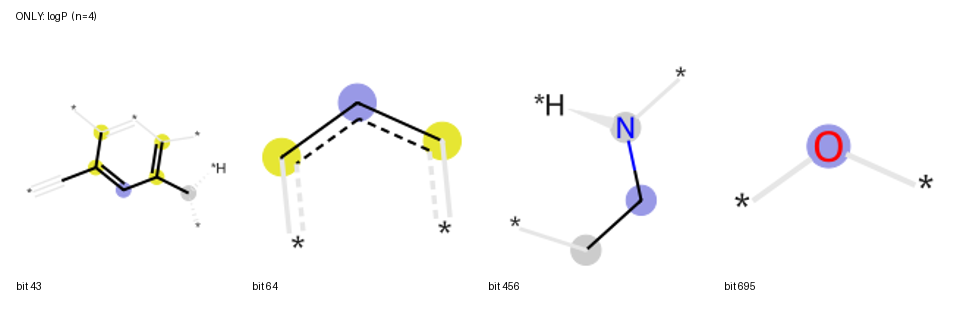

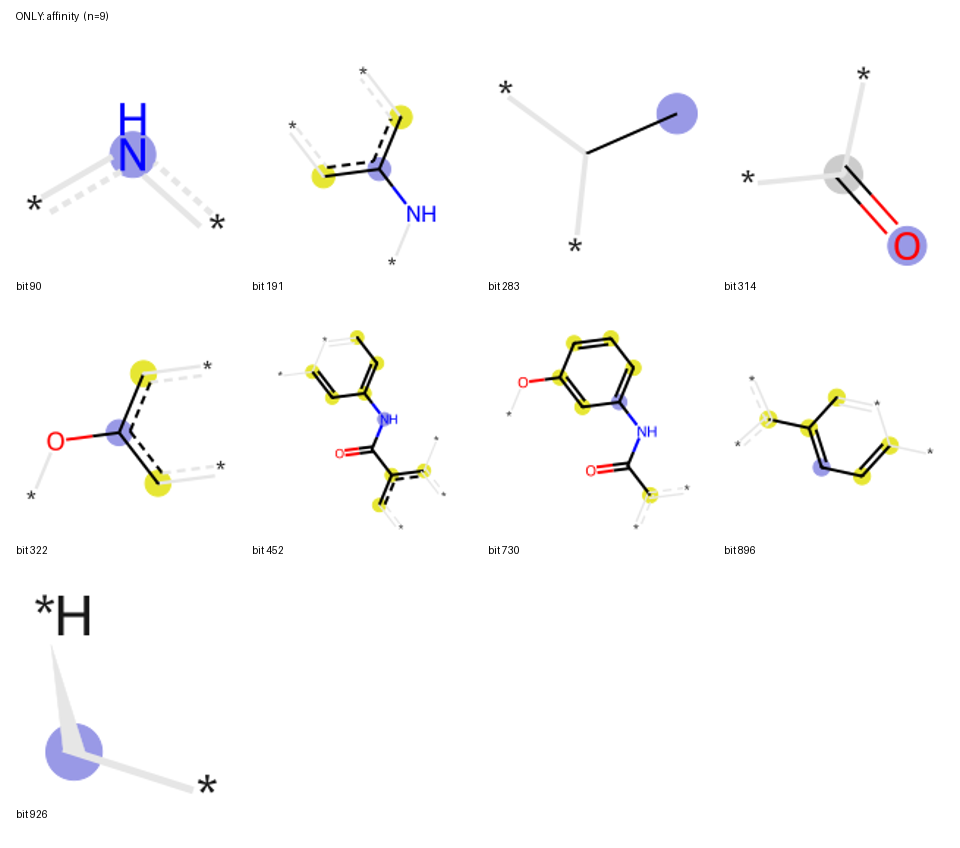

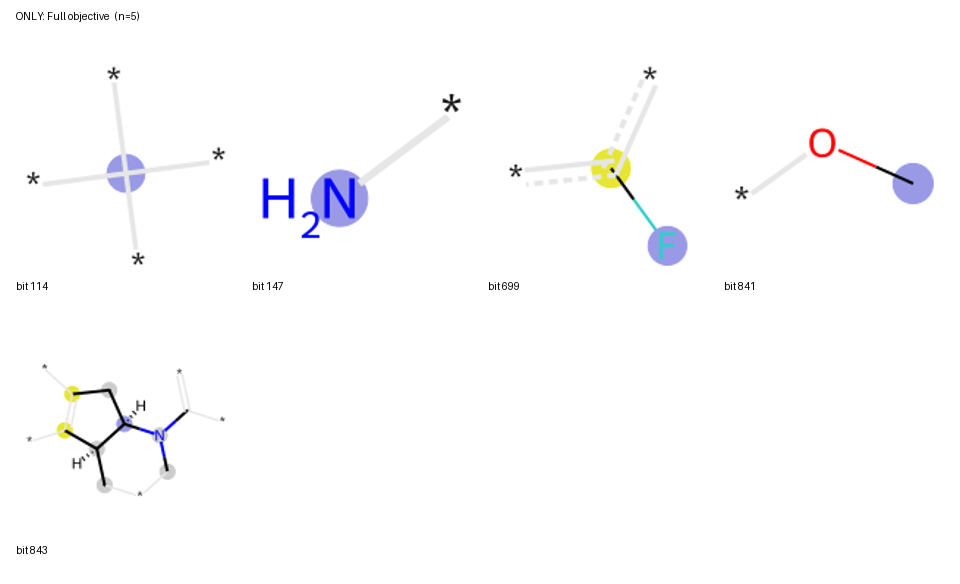

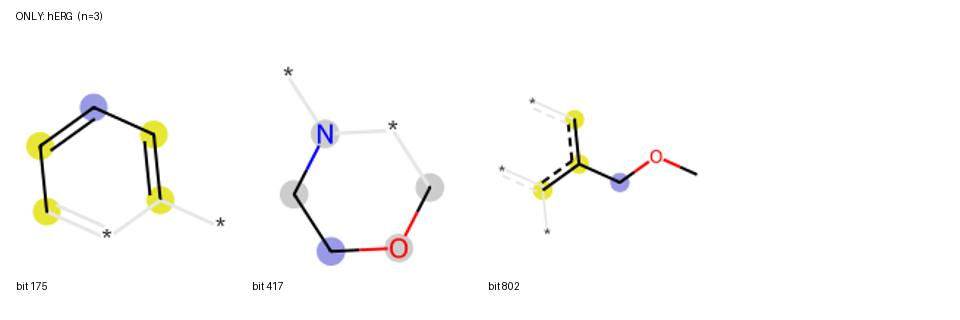

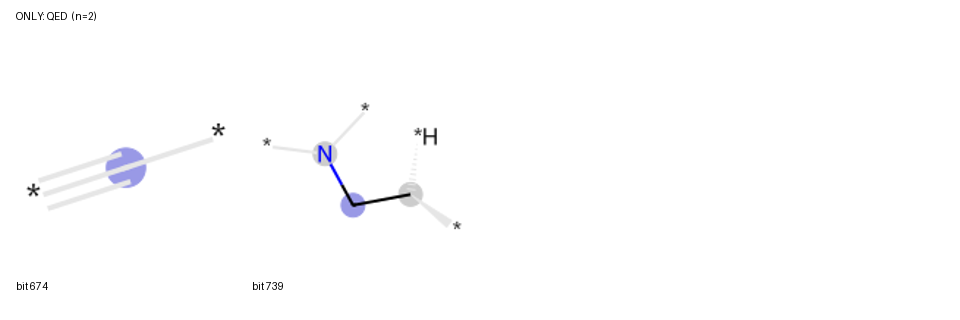

the


In [6]:
# -------------------- decode bits -> RDKit Morgan-bit environments --------------------
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Draw
    from IPython.display import display
except ImportError:
    Chem = None

def _bit_membership_regions(sets, labels):
    """Group bits by membership pattern across labels."""
    union_bits = set().union(*[sets[l] for l in labels]) if labels else set()
    pattern2bits = {}
    for b in sorted(union_bits):
        pattern = tuple(b in sets[l] for l in labels)
        pattern2bits.setdefault(pattern, []).append(b)
    return pattern2bits

def _pattern_name(pattern, labels):
    in_labs = [lab for lab, on in zip(labels, pattern) if on]
    if len(in_labs) == 0:
        return "none"
    if len(in_labs) == 1:
        return f"ONLY: {in_labs[0]}"
    if len(in_labs) == len(labels):
        return "COMMON: all runs"
    return " & ".join(in_labs)

def _find_representative_mols_for_bits(bits, smiles_list, radius=3, nBits=1024, max_scan=50000):
    """
    For each bit, find ONE molecule in smiles_list that contains it and store its bitInfo.
    Returns dict: bit -> (mol, bitInfo)
    """
    rep = {}
    missing = set(bits)

    scanned = 0
    for smi in smiles_list:
        if not missing:
            break
        scanned += 1
        if scanned > max_scan:
            break

        m = Chem.MolFromSmiles(str(smi))
        if m is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits, bitInfo=bitInfo)
        on = set(fp.GetOnBits())

        hit = list(on & missing)
        for b in hit:
            # store the WHOLE dict; DrawMorganBit needs it
            rep[b] = (m, bitInfo)
        missing -= set(hit)

    return rep, missing

def _show_bits_as_rdkit_grid(bits, rep_lookup, title, max_bits=24, mols_per_row=4, subimg=(220, 220)):
    """
    Render Morgan-bit environments as a grid using DrawMorganBit for each bit.
    We tile PIL images into a grid (because DrawMorganBit returns images, not mols).
    """
    from PIL import Image, ImageDraw, ImageFont

    bits = list(bits)[:max_bits]
    if not bits:
        print(f"{title}: (no bits)")
        return

    # Create images for each bit
    imgs = []
    legends = []
    for b in bits:
        if b not in rep_lookup:
            continue
        mol, bitInfo = rep_lookup[b]
        try:
            img = Draw.DrawMorganBit(mol, int(b), bitInfo, whichExample=0)  # PIL image
        except Exception:
            continue
        imgs.append(img.resize(subimg))
        legends.append(f"bit {b}")

    if not imgs:
        print(f"{title}: could not render any bits (no reps found).")
        return

    cols = max(1, mols_per_row)
    rows = (len(imgs) + cols - 1) // cols
    pad = 16
    label_h = 28

    W = cols * subimg[0] + (cols + 1) * pad
    H = rows * (subimg[1] + label_h) + (rows + 1) * pad + 40
    canvas = Image.new("RGB", (W, H), "white")
    draw = ImageDraw.Draw(canvas)

    # Title
    draw.text((pad, 10), title, fill="black")

    # Try a default font; if unavailable, PIL will fallback
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None

    for idx, (im, leg) in enumerate(zip(imgs, legends)):
        r = idx // cols
        c = idx % cols
        x = pad + c * (subimg[0] + pad)
        y = 40 + pad + r * (subimg[1] + label_h + pad)
        canvas.paste(im, (x, y))
        draw.text((x, y + subimg[1] + 4), leg, fill="black", font=font)

    display(canvas)

# Only run this block if RDKit is available and we have sets
if Chem is not None and sets:
    labels = list(sets.keys())

    # Load molecules you want to use to “explain” bits (train.csv in your example)
    train_path = (repo_root if "repo_root" in globals() else Path.cwd()) / "data" / "train.csv"
    if not train_path.exists():
        print(f"Cannot decode bits: missing {train_path}")
    else:
        train_df = pd.read_csv(train_path)
        smiles_col = "Drug"  # adjust if your column differs
        smiles_list = train_df[smiles_col].astype(str).tolist()

        radius, nBits = 3, 1024  # must match your bucket definition

        # Group bits by overlap regions (ONLY A, A&B, COMMON, ...)
        pattern2bits = _bit_membership_regions(sets, labels)

        # We will decode ALL bits that appear in any region
        all_bits = set().union(*pattern2bits.values()) if pattern2bits else set()
        rep_lookup, missing = _find_representative_mols_for_bits(
            all_bits, smiles_list, radius=radius, nBits=nBits, max_scan=80000
        )

        if missing:
            print(f"Warning: could not find representative molecules for {len(missing)} bits "
                  f"(may be collisions, different nBits/radius, or not present in train).")

        # Show the regions you usually care about:
        # 1) bits unique to each run (ONLY: run)
        for pattern, bits in pattern2bits.items():
            if sum(pattern) == 1:  # exclusive region
                name = _pattern_name(pattern, labels)
                _show_bits_as_rdkit_grid(bits, rep_lookup, title=f"{name}  (n={len(bits)})", max_bits=24)


        print("the")
        # 2) common to all
        for pattern, bits in pattern2bits.items():
            if sum(pattern) == len(labels) and len(labels) > 1:
                name = _pattern_name(pattern, labels)
                _show_bits_as_rdkit_grid(bits, rep_lookup, title=f"{name}  (n={len(bits)})", max_bits=24)


In [8]:
# FIXED version: saves EACH Morgan-bit image as its own file
# in a SEPARATE FOLDER per region name (ONLY: X, COMMON: all runs, etc.)

import re
from pathlib import Path
import pandas as pd

try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Draw
except ImportError:
    Chem = None


def _bit_membership_regions(sets, labels):
    union_bits = set().union(*[sets[l] for l in labels]) if labels else set()
    pattern2bits = {}
    for b in sorted(union_bits):
        pattern = tuple(b in sets[l] for l in labels)
        pattern2bits.setdefault(pattern, []).append(int(b))
    return pattern2bits


def _pattern_name(pattern, labels):
    in_labs = [lab for lab, on in zip(labels, pattern) if on]
    if len(in_labs) == 0:
        return "none"
    if len(in_labs) == 1:
        return f"ONLY: {in_labs[0]}"
    if len(in_labs) == len(labels):
        return "COMMON: all runs"
    return " & ".join(in_labs)


def _safe_folder_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace("&", "AND")
    s = s.replace(":", "")
    s = s.replace(" ", "_")
    s = re.sub(r"[^a-zA-Z0-9_\-]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:120] if len(s) > 120 else s


def _find_representative_mols_for_bits(bits, smiles_list, radius=3, nBits=1024, max_scan=50000):
    """
    For each bit, find ONE molecule in smiles_list that contains it and store its bitInfo.
    Returns dict: bit -> (mol, bitInfo)
    """
    rep = {}
    missing = set(int(b) for b in bits)

    for i, smi in enumerate(smiles_list):
        if not missing or i >= max_scan:
            break

        m = Chem.MolFromSmiles(str(smi))
        if m is None:
            continue

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits, bitInfo=bitInfo)
        on = set(fp.GetOnBits())

        hit = list(on & missing)
        for b in hit:
            rep[int(b)] = (m, bitInfo)  # keep full bitInfo dict
        missing -= set(hit)

    return rep, missing


def save_bits_as_images(
    bits,
    rep_lookup,
    out_dir,
    whichExample=0,
    max_bits=None,
    fmt="png",
    dpi_scale=4,  # higher -> bigger/sharper images (PIL resize)
):
    """
    Save each bit as its own image file in out_dir.
    Uses Draw.DrawMorganBit output (same picture you saw with blue/yellow + '*' attachments).
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    bits = list(map(int, bits))
    if max_bits is not None:
        bits = bits[: int(max_bits)]

    saved = 0
    for b in bits:
        if b not in rep_lookup:
            continue
        mol, bitInfo = rep_lookup[b]
        try:
            im = Draw.DrawMorganBit(mol, int(b), bitInfo, whichExample=int(whichExample))  # PIL image
        except Exception:
            continue

        # make higher quality by resizing up (keeps it visually crisp for papers)
        if dpi_scale and dpi_scale > 1:
            w, h = im.size
            im = im.resize((w * dpi_scale, h * dpi_scale))

        # out_png = folder / f"bit_{b}.png"
        # save_morgan_bit_png(mol, bitInfo, b, out_png, whichExample=0, size=2000)


        im.save(out_dir / f"bit_{b}.{fmt}")
        saved += 1

    return saved

from rdkit.Chem.Draw import rdMolDraw2D

from pathlib import Path

def save_bits_as_images(
    bits,
    rep_lookup,
    out_dir,
    whichExample=0,
    max_bits=None,
    png_size=1600,      # <-- increase for better PNG quality
    save_png=True,
    save_svg=True,
):
    """
    Save each bit as its own file in out_dir using RDKit Draw.DrawMorganBit.
    Produces the SAME blue/yellow '*' Morgan-bit picture you saw.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    bits = list(map(int, bits))
    if max_bits is not None:
        bits = bits[: int(max_bits)]

    saved = 0
    for b in bits:
        if b not in rep_lookup:
            continue

        tup = rep_lookup[b]
        mol, bitInfo = tup[0], tup[1]

        # ---- high-res PNG ----
        if save_png:
            try:
                im = Draw.DrawMorganBit(
                    mol, int(b), bitInfo,
                    whichExample=int(whichExample),
                    molSize=(int(png_size), int(png_size)),
                    legend=""  # no text
                )
                im.save(out_dir / f"bit_{b}.png")
            except Exception:
                pass

        # ---- SVG (best quality, vector) ----
        if save_svg:
            try:
                svg_obj = Draw.DrawMorganBit(
                    mol, int(b), bitInfo,
                    whichExample=int(whichExample),
                    molSize=(900, 900),
                    useSVG=True,
                    legend=""
                )
                (out_dir / f"bit_{b}.svg").write_text(svg_obj.data, encoding="utf-8")
            except Exception:
                pass

        saved += 1

    return saved



# -------------------- MAIN --------------------
if Chem is None:
    raise RuntimeError("RDKit is not installed in this environment.")

if "sets" not in globals() or not sets:
    raise RuntimeError("`sets` is missing/empty. Build your sets dict first (label -> set(bits)).")

labels = list(sets.keys())

# Load molecule pool for decoding bits (train.csv)
base = repo_root if "repo_root" in globals() else Path.cwd()
train_path = base / "data" / "train.csv"
if not train_path.exists():
    raise FileNotFoundError(f"Cannot decode bits: missing {train_path}")

train_df = pd.read_csv(train_path)
smiles_col = "Drug"  # change if needed
smiles_list = train_df[smiles_col].astype(str).tolist()

radius, nBits = 3, 1024  # MUST match your bucket definition

# Group bits by overlap regions
pattern2bits = _bit_membership_regions(sets, labels)

# Build representative lookup for ALL bits (one mol per bit)
all_bits = set().union(*pattern2bits.values()) if pattern2bits else set()
rep_lookup, missing = _find_representative_mols_for_bits(
    all_bits, smiles_list, radius=radius, nBits=nBits, max_scan=80000
)

if missing:
    print(f"Warning: could not find representative molecules for {len(missing)} bits.")

export_root = Path("morgan_bit_images")
export_root.mkdir(parents=True, exist_ok=True)

total = 0
for pattern, bits in pattern2bits.items():
    if not bits:
        continue
    region_name = _pattern_name(pattern, labels)
    folder = export_root / _safe_folder_name(region_name)

    saved = save_bits_as_images(
        bits=bits,
        rep_lookup=rep_lookup,
        out_dir=folder,
        whichExample=0,
        max_bits=None,
        png_size=2000,   # <-- make it very crisp
        save_png=True,
        save_svg=True,   # <-- best for paper
    )
    print(f"{region_name}: saved {saved} images -> {folder}")
    total += saved

print(f"\n✅ Done. Total saved images: {total}")
print(f"Root folder: {export_root.resolve()}")





logP & affinity: saved 1 images -> morgan_bit_images/logP_AND_affinity
hERG & Full objective: saved 2 images -> morgan_bit_images/hERG_AND_Full_objective
ONLY: logP: saved 4 images -> morgan_bit_images/ONLY_logP
ONLY: affinity: saved 9 images -> morgan_bit_images/ONLY_affinity
ONLY: Full objective: saved 5 images -> morgan_bit_images/ONLY_Full_objective
ONLY: hERG: saved 3 images -> morgan_bit_images/ONLY_hERG
QED & Full objective: saved 2 images -> morgan_bit_images/QED_AND_Full_objective
QED & hERG & Full objective & affinity: saved 1 images -> morgan_bit_images/QED_AND_hERG_AND_Full_objective_AND_affinity
logP & hERG & affinity: saved 1 images -> morgan_bit_images/logP_AND_hERG_AND_affinity
ONLY: QED: saved 2 images -> morgan_bit_images/ONLY_QED
QED & hERG: saved 1 images -> morgan_bit_images/QED_AND_hERG

✅ Done. Total saved images: 31
Root folder: /scratch/home/sr3622/Firm-DTI/Firm-DTI2/nevermore/notebooks/morgan_bit_images
